# Análisis de reseñas de `fixauto.com`

Este notebook realiza un análisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [1]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.feature_extraction import text
from transformers import pipeline
import nltk
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = 5000  # Ejemplo: 5000 para pruebas rapidas
TARGET = "fixauto.com"
CAT = "Vehicles & Transportation"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [3]:
df = pd.read_csv("data/trustpilot-reviews-123k.csv")
df.sample(10)

,category,company,description,title,review,stars
5684,Beauty & Well-being,www.design4nails.co.uk,DESIGN4NAILS & BEAUTY is an exceptional onlin...,Highly Recommend,I’ve used Design4Nails for years. They stock o...,5
55492,Money & Insurance,debitam.com,Debitam - Online Account Filing is a team of p...,Good experience,I had a good experience working with Debitam. ...,4
6854,Health & Medical,meditainment.com,A unique meditation program for improved sleep...,I honestly don't have the time to constantly g...,It's all good .,3
75797,Utilities,water2business.co.uk,At water2business our ethos is to work in part...,Great telephone service.,Great telephone service.We've had issues with ...,5
93040,Education & Training,kaplan.co.uk,Reasons why people choose Kaplan:\nExperts in ...,Easy to use website,"Easy to use website, quick payment process. B...",5
106837,Sports,runnorthwest.co.uk,Run North West is your go-to destination for a...,Poor customer service,Poor customer service,2
67652,Construction & Manufacturing,safetygloves.co.uk,Here at Safety Gloves we understand the import...,Too small a customer!,Why a company would chose to send out their go...,1
81473,Media & Publishing,pocketmags.com,Pocketmags.com - Your online magazine subscrip...,I am glad that your site exist,"I am glad that your site exist, with all these...",3
5346,Beauty & Well-being,spnnails.co.uk,Ready for fabulous nails? SPN Nails & NailLac ...,Took course and decided to try SPN,Lovely packaging - comes in fragranced tissue ...,5
62142,Travel & Vacation,www.prioritypass.com,Priority Pass provides frequent travelers with...,Great use but could be better,I have made use of this membership quite well....,4


In [4]:
#Viendo si hay valores nulos
df.isnull().sum()

category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

In [5]:
summary = pd.read_csv("data/emp_100_reviews.xlsx - Sheet1.csv")
summary.sample(10)  

,category,company,n_reviews,median_stars,media_stars,std_stars
54,Shopping & Fashion,uk.toonzshop.com,100,3,3,1.421338
11,Restaurants & Bars,www.chefonline.co.uk,100,3,3,1.421338
36,Shopping & Fashion,www.ldmountaincentre.com,100,3,3,1.421338
246,Travel & Vacation,www.travelzoo.com,100,3,3,1.421338
499,Home & Garden,best4frames.co.uk,100,3,3,1.421338
277,Travel & Vacation,trip.com,100,3,3,1.421338
211,Sports,www.sportsshoes.com,100,3,3,1.421338
376,Beauty & Well-being,nutritiongeeks.co,100,3,3,1.421338
77,Media & Publishing,www.books2door.com,100,3,3,1.421338
415,Business Services,www.energizedcustoms.co.uk,100,3,3,1.421338


In [6]:
#Viendo si hay valores nulos
summary.isnull().sum()

category        0
company         0
n_reviews       0
median_stars    0
media_stars     0
std_stars       0
dtype: int64

In [7]:
# Viendo si hay duplicados en la tabla resumen
summary.duplicated().any()

False

In [8]:
competencia = summary.query("category == @CAT & n_reviews <= 100 & company != @TARGET").company
competencia.unique()

<StringArray>
[              'brompton.com',            '1stchoice.co.uk',
               'etyres.co.uk',              'revive-uk.com',
         'farmerautocare.com',              'flixbus.co.uk',
                 'haynes.com',               'justpark.com',
          'paulscycles.co.uk',              'pod-point.com',
            'sigmasports.com',          'www.poferries.com',
         'www.national.co.uk',    'www.nationalexpress.com',
            'www.ohme-ev.com',      'www.paddockspares.com',
          'www.planetx.co.uk',      'www.plates4less.co.uk',
          'www.protyre.co.uk',   'taxis.gatwickairport.com',
     'www.regtransfers.co.uk',    'www.sportandleisure.com',
       'www.thetrainline.com',            'www.tredz.co.uk',
        'www.webuyanycar.com', 'www.winstanleysbikes.co.uk',
       'www.merlincycles.com',  'www.leisurelakesbikes.com',
           'www.kwik-fit.com',     'www.huntbikewheels.com',
           'www.halfords.com',      'www.ferryonline.co.uk',
    'www.f

## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [9]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

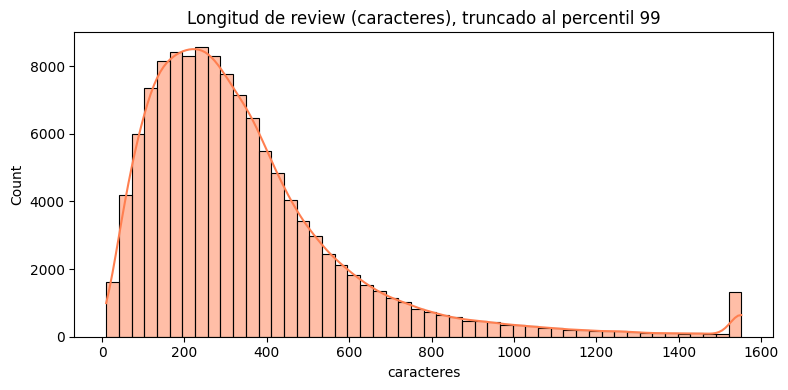

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [11]:
import re

def limpieza(texto: str) -> str:
    texto = texto.replace("\n", " ")        # elimina saltos de línea
    texto = texto.lower()                   # a minúsculas
    texto = re.sub(r"[^\w ]+", "", texto)   # elimina caracteres especiales
    return texto

df = df.assign(
    title       = df.title.apply(limpieza),
    review      = df.review.apply(limpieza),
    description = df.description.apply(limpieza)
)

In [12]:
#Viendo si hay duplicados
df.duplicated().any()

False

## 6) Filtrado del sector de la compañía objetivo

In [13]:
#Datos de la competencia
df_competencia=df[df.company.isin(competencia)]
#Datos de la empresa
df_empresa=df[df.company==TARGET]

In [14]:
df_competencia.sample(10)

,category,company,description,title,review,stars,review_len
79641,Vehicles & Transportation,www.huntbikewheels.com,hunt bike wheels exists because the wheels we ...,wheels were faulty,wheels were faulty took weeks to get agreement...,1,527
78049,Vehicles & Transportation,www.merlincycles.com,merlin cycles is one of the uks leading intern...,great products at good prices,great products at good prices very quick to sh...,5,130
81060,Vehicles & Transportation,www.paddockspares.com,aew paddock motors was set up in 1975 our inte...,they respond and process an order,they respond and process an order promptly and...,4,322
122379,Vehicles & Transportation,justpark.com,justpark makes parking easier for over 13 mill...,it was in a very nice location,it was in a very nice location it was walking ...,4,180
77339,Vehicles & Transportation,www.thetrainline.com,were trainline europes leading rail and bus ap...,super easy to buy ticket,super easy to buy ticket live tracker which yo...,5,184
76147,Vehicles & Transportation,www.nationalexpress.com,its about more than just getting from here to ...,be aware that buying flexible may not,be aware that buying flexible may not entitle ...,3,81
76263,Vehicles & Transportation,www.poferries.com,po ferries has a fleet of more than 20 ships a...,the food was cold and i beleive i have,the food was cold and i beleive i have been ro...,2,270
79925,Vehicles & Transportation,paulscycles.co.uk,fast reliable delivery built prepared check...,customer service was appalling after,customer service was appalling after contactin...,2,392
80825,Vehicles & Transportation,etyres.co.uk,etyres have taken the headache out of buying n...,nonexistant fitting appointment,etyres booked a fitting appointment without kn...,1,521
122632,Vehicles & Transportation,www.ohme-ev.com,an intelligent way to charge auto express re...,not enough engineers to fit,having brought our first electric car i had to...,2,315


In [15]:
df_empresa.sample(10)

,category,company,description,title,review,stars,review_len
121977,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,fix auto were really good with the,fix auto were really good with the repair afte...,4,473
121992,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,it took some to get authorisation from,it took some to get authorisation from aviva b...,4,179
121961,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,efficient service regular contact with the cus...,vehicle off the road for a month which coincid...,5,354
122053,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,avoid at all costs a nightmare experience,i had the unfortunate experience of dealing wi...,1,1314
121973,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,excellent communication,excellent communication very easy to deal wi...,5,202
122021,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,first off they disconnected my dashcam,first off they disconnected my dashcam then so...,2,404
121990,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,good clean job lovely colour match,good clean job great colour match cant see whe...,4,748
122017,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,communication,communication booked in a repair for a van pa...,2,778
122023,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,disappointed with the service,the actual repair body work was good but the i...,2,288
121983,Vehicles & Transportation,fixauto.com,fix auto uk have a nationwide network of over ...,great service,i was really pleased by the service provided ...,4,480


In [16]:
stars_prom= pd.DataFrame({
    "Empresa": [ TARGET, "Competencia"],
    "Stars promedio": [df_empresa.stars.mean().round(2), df_competencia.stars.mean().round(2)]
})
display(stars_prom)

,Empresa,Stars promedio
0,fixauto.com,3.0
1,Competencia,3.0


## 7) Sentimiento
Aplicamos el análisis de sentimiento sobre `df_empresa` y `df_competencia` respecto a `review` usando un modelo de HuggingFace.

In [17]:
# Sentimiento con pipeline de HuggingFace (distilbert-sst2, rapido y ligero)
# Truncamos a 512 tokens que es el maximo del modelo
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    device=-1  # CPU; cambia a 0 si tienes GPU
)

def batch_sentiment(texts, batch_size=64):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size].tolist()
        out = sentiment_pipe(batch)
        results.extend(out)
    labels = [r["label"] for r in results]
    scores = [r["score"] for r in results]
    return labels, scores

# --- data_empresa ---
print("Analizando sentimiento de la empresa...")
labels_e, scores_e = batch_sentiment(df_empresa["review"])
data_empresa = df_empresa.copy()
data_empresa["sentiment"]       = labels_e
data_empresa["sentiment_score"] = scores_e

# --- data_competencia ---
print("Analizando sentimiento de la competencia...")
labels_c, scores_c = batch_sentiment(df_competencia["review"])
data_competencia = df_competencia.copy()
data_competencia["sentiment"]       = labels_c
data_competencia["sentiment_score"] = scores_c

print("Listo.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Analizando sentimiento de la empresa...
Analizando sentimiento de la competencia...
Listo.


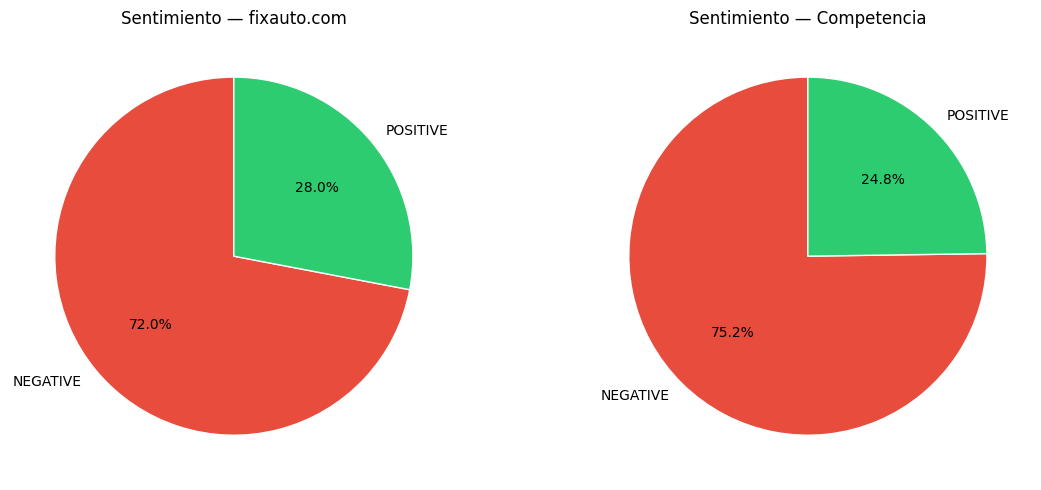

,empresa,competencia
sentiment,,
NEGATIVE,72,3310
POSITIVE,28,1090


In [18]:
# Resumen de sentimiento
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e74c3c", "#2ecc71"]

for ax, (df_plot, label) in zip(axes, [(data_empresa, TARGET), (data_competencia, "Competencia")]):
    counts = df_plot["sentiment"].value_counts()
    ax.pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )
    ax.set_title(f"Sentimiento — {label}")

plt.tight_layout()
plt.show()

# Tabla resumen
pd.DataFrame({
    "empresa": data_empresa["sentiment"].value_counts(),
    "competencia": data_competencia["sentiment"].value_counts()
})

## 8 Topics con BERTopic

In [19]:
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

_lemmatizer = WordNetLemmatizer()
_stop_words = set(CountVectorizer(stop_words="english").get_stop_words()) | {
    "wasnt", "wasnt", "didnt", "dont", "doesnt", "wouldnt", "couldnt",
    "shouldnt", "isnt", "arent", "werent", "havent", "hasnt", "hadnt",
    "wont", "cant", "ive", "im", "ive", "youre", "theyre", "weve",
    "theyve", "id", "wed", "theyd", "youll", "theyll", "thats", "whos"
}

def lemmatize_tokenizer(doc):
    import re
    # Solo tokens de 2+ letras puras (sin dígitos ni caracteres especiales)
    tokens = re.findall(r"\b[a-zA-Z]{2,}\b", doc)
    lemmas = []
    for t in tokens:
        t = t.lower()
        if t in _stop_words:
            continue
        lemma = _lemmatizer.lemmatize(t, pos="v")
        if lemma == t:
            lemma = _lemmatizer.lemmatize(t, pos="n")
        lemmas.append(lemma)
    return lemmas

def entrenar_bertopic(docs, n_topics=N_TOPICS):
    vectorizer = CountVectorizer(
        tokenizer=lemmatize_tokenizer,
        lowercase=False,
        min_df=2
    )
    model = BERTopic(
        vectorizer_model=vectorizer,
        nr_topics=n_topics,
        language="english",
        calculate_probabilities=False,
        verbose=True
    )
    topics, _ = model.fit_transform(docs)
    return model, topics

# --- data_empresa ---
print("=== BERTopic: data_empresa ===")
docs_empresa = data_empresa["review"].tolist()
model_empresa, topics_empresa = entrenar_bertopic(docs_empresa)
data_empresa["topic"] = topics_empresa

# --- data_competencia ---
print("\n=== BERTopic: data_competencia ===")
docs_competencia = data_competencia["review"].tolist()
model_compet, topics_competencia = entrenar_bertopic(docs_competencia)
data_competencia["topic"] = topics_competencia

print("\nListo.")

2026-06-17 16:21:56,389 - BERTopic - Embedding - Transforming documents to embeddings.


=== BERTopic: data_empresa ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026-06-17 16:22:01,457 - BERTopic - Embedding - Completed ✓
2026-06-17 16:22:01,457 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-17 16:22:12,004 - BERTopic - Dimensionality - Completed ✓
2026-06-17 16:22:12,005 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-17 16:22:12,021 - BERTopic - Cluster - Completed ✓
2026-06-17 16:22:12,021 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-17 16:22:14,711 - BERTopic - Representation - Completed ✓
2026-06-17 16:22:14,712 - BERTopic - Topic reduction - Reducing number of topics
2026-06-17 16:22:14,713 - BERTopic - Topic reduction - Number of topics (8) is equal or higher than the clustered topics(3).
2026-06-17 16:22:14,713 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-17 16:22:14,755 - BERTopic - Representation - Completed ✓
2026-06-17 16:22:14,792 - BERTopic - Embedding - Transforming documents to emb


=== BERTopic: data_competencia ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/138 [00:00<?, ?it/s]

2026-06-17 16:22:57,445 - BERTopic - Embedding - Completed ✓
2026-06-17 16:22:57,445 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-17 16:23:13,837 - BERTopic - Dimensionality - Completed ✓
2026-06-17 16:23:13,838 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-17 16:23:13,970 - BERTopic - Cluster - Completed ✓
2026-06-17 16:23:13,971 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-17 16:23:14,759 - BERTopic - Representation - Completed ✓
2026-06-17 16:23:14,760 - BERTopic - Topic reduction - Reducing number of topics
2026-06-17 16:23:14,785 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-17 16:23:15,534 - BERTopic - Representation - Completed ✓
2026-06-17 16:23:15,535 - BERTopic - Topic reduction - Reduced number of topics from 52 to 8



Listo.


In [20]:
# Topics de data_empresa
print("=== Topics — data_empresa ===")
info_empresa = model_empresa.get_topic_info()
display(info_empresa[info_empresa.Topic != -1][["Topic", "Count", "Name"]].head(N_TOPICS))

print("\n=== Topics — data_competencia ===")
info_compet = model_compet.get_topic_info()
display(info_compet[info_compet.Topic != -1][["Topic", "Count", "Name"]].head(N_TOPICS))

=== Topics — data_empresa ===


,Topic,Count,Name
1,0,77,0_car_repair_day_work
2,1,10,1_communication_phone_do_customer



=== Topics — data_competencia ===


,Topic,Count,Name
1,0,1313,0_tyre_bike_fit_wheel
2,1,836,1_book_park_time_driver
3,2,754,2_car_service_plate_work
4,3,298,3_delivery_order_item_product
5,4,84,4_manual_haynes_information_online
6,5,83,5_mat_fit_quality_car
7,6,71,6_size_glove_return_order


In [21]:
# Visualizacion de topics — barchart de palabras clave por topic
for model, label in [(model_empresa, TARGET), (model_compet, "Competencia")]:
    n_real = len([t for t in model.get_topics() if t != -1])
    if n_real == 0:
        print(f"[{label}] No se encontraron topics significativos (todos son outliers).")
        continue
    top_n = min(n_real, N_TOPICS)
    fig = model.visualize_barchart(top_n_topics=top_n, n_words=TOP_WORDS, title=f"Topics — {label}")
    fig.show()

=== Sentimiento por topic — data_empresa ===


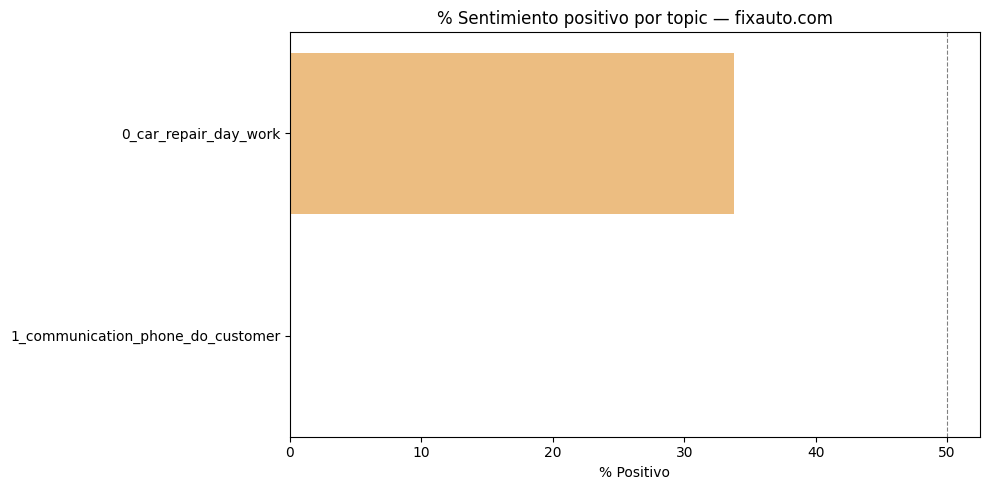

,topic_name,n_reviews,pct_positive
0,0_car_repair_day_work,77,33.8
1,1_communication_phone_do_customer,10,0.0



=== Sentimiento por topic — data_compet ===


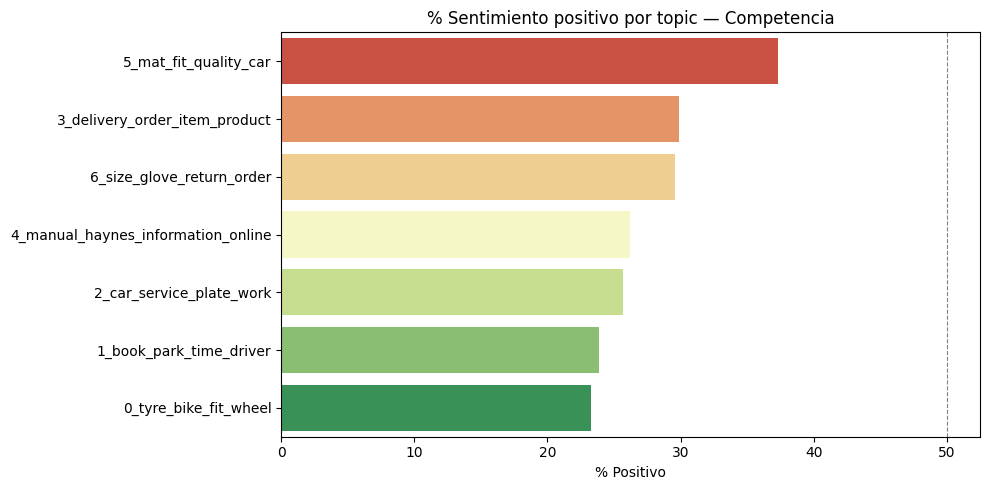

,topic_name,n_reviews,pct_positive
0,5_mat_fit_quality_car,83,37.3
1,3_delivery_order_item_product,298,29.9
2,6_size_glove_return_order,71,29.6
3,4_manual_haynes_information_online,84,26.2
4,2_car_service_plate_work,754,25.7
5,1_book_park_time_driver,836,23.9
6,0_tyre_bike_fit_wheel,1313,23.3


In [22]:
# Sentimiento por topic
def sentiment_por_topic(df_in, model, label):
    topic_names = model.get_topic_info().set_index("Topic")["Name"].to_dict()
    df_tmp = df_in[df_in["topic"] != -1].copy()
    df_tmp["topic_name"] = df_tmp["topic"].map(topic_names)
    df_tmp["positive"] = (df_tmp["sentiment"] == "POSITIVE").astype(int)

    agg = (df_tmp.groupby("topic_name")
           .agg(n_reviews=("positive", "count"),
                pct_positive=("positive", "mean"))
           .sort_values("pct_positive", ascending=False)
           .reset_index())
    agg["pct_positive"] = (agg["pct_positive"] * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=agg, x="pct_positive", y="topic_name", palette="RdYlGn", ax=ax)
    ax.set_title(f"% Sentimiento positivo por topic — {label}")
    ax.set_xlabel("% Positivo")
    ax.set_ylabel("")
    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()
    return agg

print("=== Sentimiento por topic — data_empresa ===")
sent_empresa = sentiment_por_topic(data_empresa, model_empresa, TARGET)
display(sent_empresa)

print("\n=== Sentimiento por topic — data_compet ===")
sent_competencia = sentiment_por_topic(data_competencia, model_compet, "Competencia")
display(sent_competencia)